In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
import datetime
from ipywidgets import interact, FloatSlider
import seaborn as sns

In [2]:
data = "Mapragg_MG1_training_real_measurements.parquet"

In [3]:
df =  pd.read_parquet(data, engine='pyarrow')
print(df)

                                      ts plant  signal_id      value
0       2020-06-03 04:55:48.949000+00:00   KSL       9620   0.000000
1       2020-06-03 04:56:32.952000+00:00   KSL       9619   1.000000
2       2020-06-03 08:51:59.968000+00:00   KSL      11331  44.220894
3       2020-06-03 08:52:02.412000+00:00   KSL      11247  54.700966
4       2020-06-03 08:52:08.267000+00:00   KSL      11331  44.305843
...                                  ...   ...        ...        ...
4628066 2021-06-21 15:48:08.841000+00:00   KSL      11247  52.954853
4628067 2021-06-21 15:48:11.180000+00:00   KSL       8890  80.153839
4628068 2021-06-21 15:48:16.717000+00:00   KSL       8890  80.270996
4628069 2021-06-21 15:48:20.339000+00:00   KSL      11333  46.149696
4628070 2021-06-21 15:48:21.156000+00:00   KSL      11247  53.041576

[4628071 rows x 4 columns]


In [4]:
df["value"] = df[["value"]]
timestamp = pd.to_datetime(df["ts"])
# Create linear time axis
t0 = timestamp.iloc[0]                  # reference time
df["time"] = (df["ts"] - t0).dt.total_seconds()

print(df)

                                      ts plant  signal_id      value  \
0       2020-06-03 04:55:48.949000+00:00   KSL       9620   0.000000   
1       2020-06-03 04:56:32.952000+00:00   KSL       9619   1.000000   
2       2020-06-03 08:51:59.968000+00:00   KSL      11331  44.220894   
3       2020-06-03 08:52:02.412000+00:00   KSL      11247  54.700966   
4       2020-06-03 08:52:08.267000+00:00   KSL      11331  44.305843   
...                                  ...   ...        ...        ...   
4628066 2021-06-21 15:48:08.841000+00:00   KSL      11247  52.954853   
4628067 2021-06-21 15:48:11.180000+00:00   KSL       8890  80.153839   
4628068 2021-06-21 15:48:16.717000+00:00   KSL       8890  80.270996   
4628069 2021-06-21 15:48:20.339000+00:00   KSL      11333  46.149696   
4628070 2021-06-21 15:48:21.156000+00:00   KSL      11247  53.041576   

                 time  
0        0.000000e+00  
1        4.400300e+01  
2        1.417102e+04  
3        1.417346e+04  
4        1.4179

In [5]:
def make_window_plotter(df, time_col="time", value_col="value", title_name = "title_name", y_axis_name = "y_axis_name"):
    """Return an interactive time-window plotter for a given dataframe."""
    
    def plot_window(start_s=0, window_s=100_000):
        end_s = start_s + window_s
        mask = (df[time_col] >= start_s) & (df[time_col] <= end_s)

        df_slice = df.loc[mask]

        if df_slice.empty:
            print("No data in this window")
            return

        # optional thinning
        df_slice = df_slice.iloc[::10]

        plt.figure(figsize=(12,4))
        plt.plot(df_slice[time_col], df_slice[value_col], ".", markersize=2)
        plt.title(f"{title_name}")
        plt.xlabel("Time (s)")
        plt.ylabel(f"{y_axis_name}")
        plt.show()

    # build interactive widget
    interact(
        plot_window,
        start_s=FloatSlider(min=0, max=df[time_col].max(), step=50_000, value=0),
        window_s=FloatSlider(min=50_0, max=2_000_000_0, step=50_0, value=200_000),
    )

    return plot_window  


In [6]:
unique_signal_ids = pd.unique(df["signal_id"])
print(unique_signal_ids)

[ 9620  9619 11331 11247  8890 11333]


In [7]:
sid = 11861
df_sig = df[df["signal_id"] == sid]
print(df_sig)



Empty DataFrame
Columns: [ts, plant, signal_id, value, time]
Index: []


In [8]:
mapping = {
    13413: "active_power",
    9620: "ball_valve_closed",
    9619: "ball_valve_open",
    11247: "guide_vane_position",
    11863: "water_pressure_downstream",
    11861: "water_pressure_upstream"
}

df["signal_id"] = df["signal_id"].replace(mapping)

reverse_mapping = {v: k for k, v in mapping.items()}

df_closed = df[df["signal_id"] == "ball_valve_closed"]
df_open = df[df["signal_id"] == "ball_valve_open"]
df_pwr = df[df["signal_id"] == "active_power"]
df_vane = df[df["signal_id"] == "guide_vane_position"]
df_down = df[df["signal_id"] == "water_pressure_downstream"]
df_up = df[df["signal_id"] == "water_pressure_upstream"]

In [9]:
plotter_pwr = make_window_plotter(df_pwr, title_name="Power with regard to time", y_axis_name="Power [W]")

plotter_open = make_window_plotter(df_open, title_name="Valve open status with regard to time", y_axis_name="Valve open state [-]")

plotter_closed = make_window_plotter(df_closed, title_name="Valve closed status with regard to time", y_axis_name="Valve closed state [-]")

plotter_vane = make_window_plotter(df_vane, title_name="Vane opening with regard to time", y_axis_name="Vane opening [%]")

plotter_down = make_window_plotter(df_down, title_name="Pressure downstream with regard to time", y_axis_name="P downstream [bar]")

plotter_up = make_window_plotter(df_up, title_name="Pressure upstream with regard to time", y_axis_name="P upstream [bar]")

/Users/matasjones/Desktop/ML4PM_Project/axpo_challenge/venv/lib/python3.13/site-packages/jupyter_client/session.py:721: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant: nan
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


interactive(children=(FloatSlider(value=0.0, description='start_s', max=nan, step=50000.0), FloatSlider(value=…

interactive(children=(FloatSlider(value=0.0, description='start_s', max=33127133.924, step=50000.0), FloatSlid…

interactive(children=(FloatSlider(value=0.0, description='start_s', max=33127089.422, step=50000.0), FloatSlid…

interactive(children=(FloatSlider(value=0.0, description='start_s', max=33130352.207, step=50000.0), FloatSlid…

interactive(children=(FloatSlider(value=0.0, description='start_s', max=nan, step=50000.0), FloatSlider(value=…

interactive(children=(FloatSlider(value=0.0, description='start_s', max=nan, step=50000.0), FloatSlider(value=…

In [21]:
def correlation_heatmap(df, time_col="ts", id_col="signal_id", value_col="value"):
    """
    Create a correlation heatmap between different signal_id value series.
    Data is pivoted so each signal_id becomes a column.
    """

    # Ensure datetime index
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df[[time_col, id_col, value_col]]

    # Pivot: rows = time, columns = signal_id, values = value
    # If multiple entries share the same timestamp → aggregate with mean
    pivot_df = (
        df.pivot_table(index=time_col, columns=id_col, values=value_col, aggfunc="mean")
        .sort_index()
    )

    # Compute correlation
    corr = pivot_df.corr()

    # Plot heatmap
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, cmap="vlag", annot=False)
    plt.title("Correlation between signal_id value time-series")
    plt.tight_layout()
    plt.show()

    return corr, pivot_df


In [22]:
df["ts"] = pd.to_datetime(df["ts"])
pv = df.pivot_table(index="ts", columns="signal_id", values="value", aggfunc="mean")

# Resample to 10 seconds
pv = pv.resample("40000s").mean()

# Interpolate continuous signals
pv = pv.interpolate("time")

# EWM smoothing (optional)
pv = pv.ewm(alpha=0.2).mean()

pv.head()

pv = pv.sort_index()
pv["time"] = (pv.index - pv.index[0]).total_seconds()


In [23]:
print(pv)

signal_id                       8890      11331      11333  valve_closed  \
ts                                                                         
2020-06-03 00:00:00+00:00  72.021590  45.389848  33.945746      0.500000   
2020-06-03 11:06:40+00:00  75.111048  45.680902  34.555962      0.500000   
2020-06-03 22:13:20+00:00  81.776638  45.312164  33.699585      0.500000   
2020-06-04 09:20:00+00:00  64.774279  45.653857  22.330633      0.471771   
2020-06-04 20:26:40+00:00  37.115420  45.922059  21.462568      0.430589   
...                              ...        ...        ...           ...   
2021-06-19 11:33:20+00:00  32.948043  46.132285  22.465738      0.637093   
2021-06-19 22:40:00+00:00  16.356113  46.321324  20.933979      0.609675   
2021-06-20 09:46:40+00:00  17.619854  46.459088  23.618863      0.487740   
2021-06-20 20:53:20+00:00  32.338308  46.495561  26.394411      0.490192   
2021-06-21 08:00:00+00:00  40.678273  46.591534  28.188694      0.492153   

signal_id  

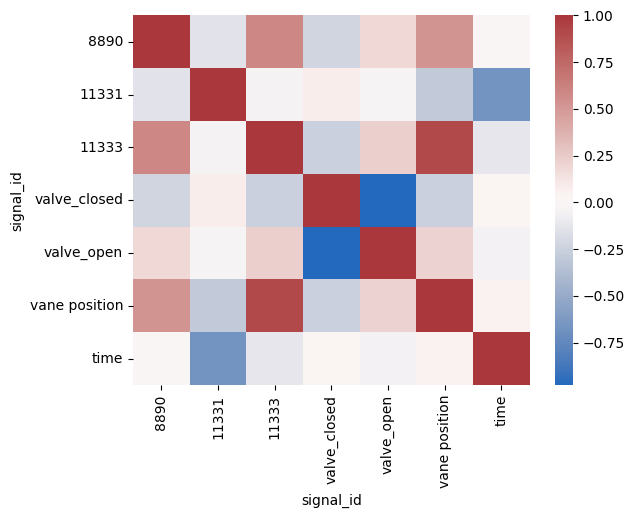

In [24]:
corr = pv.corr()
sns.heatmap(corr, cmap="vlag")
plt.show()


In [25]:
plt.figure(figsize=(12,4))
plt.plot(pv["time"], pv["active_power"], "-", markersize=3)
plt.title("Active Power with regard to time")
plt.xlabel("Time (s)")
plt.ylabel("Active power [MW]")
plt.show()

KeyError: 'active_power'

<Figure size 1200x400 with 0 Axes>

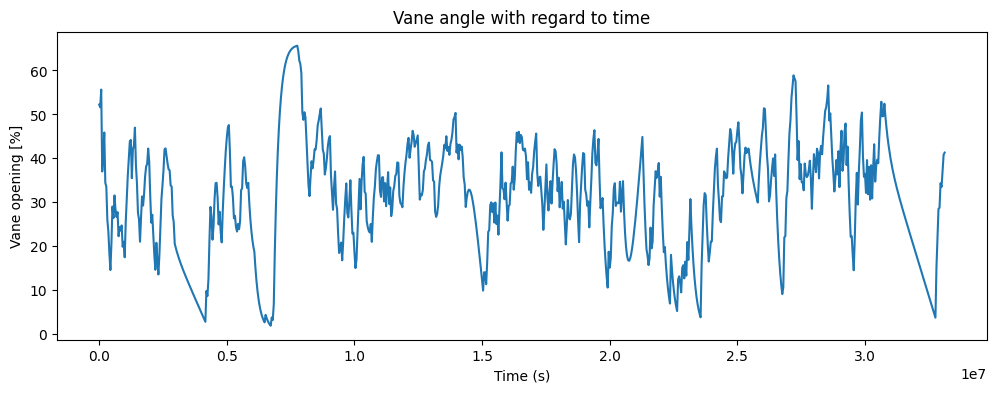

In [26]:
plt.figure(figsize=(12,4))
plt.plot(pv["time"], pv["vane position"], "-", markersize=3)
plt.title("Vane angle with regard to time")
plt.xlabel("Time (s)")
plt.ylabel("Vane opening [%]")
plt.show()

In [30]:
plt.figure(figsize=(12,4))
plt.plot(pv["time"], pv["water_pressure_upstream"], "-", markersize=3)
plt.title("Water pressure upstream with regard to time")
plt.xlabel("Time (s)")
plt.ylabel("Water pressure upstream [bar]")
plt.show()

KeyError: 'water_pressure_upstream'

<Figure size 1200x400 with 0 Axes>

In [28]:
plt.figure(figsize=(12,4))
plt.plot(pv["time"], pv["P downstream"], "-", markersize=3)
plt.title("Water pressure downstream with regard to time")
plt.xlabel("Time (s)")
plt.ylabel("Water pressure downstream [bar]")
plt.show()

KeyError: 'P downstream'

<Figure size 1200x400 with 0 Axes>

In [29]:
plt.figure(figsize=(12,4))
plt.plot(pv["time"], pv["P downstream"], "-", markersize=3)
plt.plot(pv["time"], pv["P upstream"], "-", markersize=3)
plt.title("Water pressure downstream with regard to time")
plt.xlabel("Time (s)")
plt.ylabel("Water pressure downstream [bar]")
plt.show()

KeyError: 'P downstream'

<Figure size 1200x400 with 0 Axes>